In [1]:
# Install dependencies

!pip install transformers==4.40.2
!pip install torch
!pip install accelerate
!pip install sentencepiece
!pip install scikit-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Project setup

from pathlib import Path
import os

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
elif (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
else:
    raise Exception("Project root not found")

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\LENOVO\OneDrive\Documents\Strath\Masters\sentiment-analysis-tool


In [3]:
import numpy as np
import pandas as pd
import random
import torch

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Reproducibility configured")

Reproducibility configured


In [4]:
# Import necessary libraries

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load the annotated dataset

DATA_PATH = PROJECT_ROOT / "data" / "annotated_data" / "final_annotated_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2000, 14)


,text,topic,sentiment,annotator,confidence,match_key,match_text,source,date,channel,product,language,clean_text,match_score
0,i am writing to seek urgent assistance regardi...,Mobile Banking App,negative,annotator_1,high,i am writing to seek urgent assistance regardi...,i am writing to seek urgent assistance regardi...,CRM Tool,04/11/2025 00:00,Service Email,Mobile,english,i am writing to seek urgent assistance regardi...,99.737877
1,name seem to neglect your duty to give the bes...,Mobile Banking App,negative,annotator_1,high,name seem to neglect your duty to give the bes...,name seem to neglect your duty to give the bes...,CRM Tool,05/11/2025 00:00,Service Email,Mobile,english,seem to neglect your duty to give the best bec...,98.245614
2,namere seeking your assistance in providing ...,Payments,negative,annotator_1,high,namere seeking your assistance in providing a ...,namere seeking your assistance in providing a ...,CRM Tool,05/12/2025 00:00,Service Email,Thunes,english,namere seeking your assistance in providing a ...,88.442623
3,reminder on resolving this issue of payment ...,Acccount Issues,negative,annotator_1,high,reminder on resolving this issue of payment on...,reminder on resolving this issue of payment on...,CRM Tool,19/11/2025 00:00,Service Email,Card Online Disputes,english,name name reminder on resolving this issue of ...,97.071130
4,a member of you service and am trying to open...,Mobile Banking App,negative,annotator_1,high,a member of you service and am trying to open ...,a member of you service and am trying to open ...,CRM Tool,25/11/2025 00:00,Service Email,Mobile,english,namename a member of you service and am trying...,97.352342


In [6]:
# Encode sentiment labels

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].str.lower().map(label_map)

df[["sentiment","label"]].head()

,sentiment,label
0,negative,0
1,negative,0
2,negative,0
3,negative,0
4,negative,0


In [7]:
# Define features and labels

X = df["clean_text"]
y = df["label"]

print("Total samples:", len(X))

Total samples: 2000


In [8]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 1600
Test size: 400


In [9]:
# Create a validation set

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

print("Final train size:", len(X_train_final))
print("Validation size:", len(X_val))

Final train size: 1440
Validation size: 160


In [10]:
# Increase timeout for hugging face download
import os
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"

In [11]:
# Load finBERT model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"

# Download tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Download model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

print("FinBERT loaded successfully")

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


FinBERT loaded successfully


In [12]:
# Save the model and tokenizer to the project directory for faster loading in the future

MODEL_PATH = PROJECT_ROOT / "models" / "finbert"

model.save_pretrained(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("FinBERT saved locally")

FinBERT saved locally


In [13]:
# Tokenize the datasets

train_encodings = tokenizer(
    X_train_final.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization complete")

Tokenization complete


In [14]:
# Create pyTorch dataset class

class BankingDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [15]:
# Create dataset objects

train_dataset = BankingDataset(
    train_encodings,
    y_train_final.tolist()
)

val_dataset = BankingDataset(
    val_encodings,
    y_val.tolist()
)

test_dataset = BankingDataset(
    test_encodings,
    y_test.tolist()
)

print("Datasets ready")

Datasets ready


In [16]:
# Define evaluation metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    }

In [17]:
# Define training arguments

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir=str(PROJECT_ROOT / "models" / "finbert_tuning"),

    evaluation_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    seed=SEED,

    report_to="none"
)

In [18]:
# Define model initialization for hyperparameter tuning

def model_init():

    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    )

In [19]:
# Create a trainer

from transformers import Trainer

trainer = Trainer(

    model_init=model_init,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [20]:
# Define hyperparameter search space

def hp_space(trial):

    return {

        "learning_rate": trial.suggest_categorical(
            "learning_rate",
            [5e-5, 3e-5, 2e-5]
        ),

        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size",
            [8, 16]
        ),

        "num_train_epochs": trial.suggest_categorical(
            "num_train_epochs",
            [3, 4]
        ),

        "weight_decay": trial.suggest_categorical(
            "weight_decay",
            [0.01, 0.1]
        ),
    }

In [21]:
# Perform hyperparameter search with Optuna

best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    n_trials=2, 
)

print("Best run:", best_run)

[I 2026-04-05 12:55:23,193] A new study created in memory with name: no-name-35c4b04f-e39c-4938-a8f8-6857d981c048
  0%|          | 0/360 [00:00<?, ?it/s]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                  
 25%|██▌       | 90/360 [11:47<1:13:51, 16.41s/it]

{'eval_loss': 0.37350502610206604, 'eval_Accuracy': 0.85, 'eval_F1': 0.8506180139253153, 'eval_Precision': 0.854959301262118, 'eval_Recall': 0.85, 'eval_runtime': 14.9913, 'eval_samples_per_second': 10.673, 'eval_steps_per_second': 1.334, 'epoch': 1.0}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                     
 50%|█████     | 180/360 [39:17<23:17,  7.76s/it]

{'eval_loss': 0.34180518984794617, 'eval_Accuracy': 0.89375, 'eval_F1': 0.8935574477969583, 'eval_Precision': 0.8999573635634028, 'eval_Recall': 0.89375, 'eval_runtime': 472.8929, 'eval_samples_per_second': 0.338, 'eval_steps_per_second': 0.042, 'epoch': 2.0}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                      
 75%|███████▌  | 270/360 [1:01:24<2:32:19, 101.55s/it]

...

{'loss': 0.4034, 'grad_norm': 24.273143768310547, 'learning_rate': 1.4814814814814815e-06, 'epoch': 2.78}


                                                   
100%|██████████| 540/540 [1:26:45<00:00,  4.44s/it]

{'eval_loss': 0.3333943784236908, 'eval_Accuracy': 0.88125, 'eval_F1': 0.8809961417543111, 'eval_Precision': 0.8841629616487156, 'eval_Recall': 0.88125, 'eval_runtime': 22.9515, 'eval_samples_per_second': 6.971, 'eval_steps_per_second': 0.871, 'epoch': 3.0}


100%|██████████| 540/540 [1:26:46<00:00,  9.64s/it]
[I 2026-04-05 15:49:34,293] Trial 1 finished with value: 3.527659103403027 and parameters: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.1}. Best is trial 0 with value: 3.6997759780637622.


{'train_runtime': 5206.6517, 'train_samples_per_second': 0.83, 'train_steps_per_second': 0.104, 'train_loss': 0.38382321022174976, 'epoch': 3.0}
Best run: BestRun(run_id='0', objective=3.6997759780637622, hyperparameters={'learning_rate': 5e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 4, 'weight_decay': 0.01}, run_summary=None)


In [22]:
best_params = best_run.hyperparameters
print("Best params:", best_params)

Best params: {'learning_rate': 5e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 4, 'weight_decay': 0.01}


In [23]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

final_training_args = TrainingArguments(
    output_dir="finbert_final",

    evaluation_strategy="epoch",
    save_strategy="epoch",

    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["per_device_train_batch_size"],
    num_train_epochs=best_params["num_train_epochs"],
    weight_decay=best_params["weight_decay"],

    logging_dir="./logs",
    report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# 🚀 FINAL TRAINING (this creates real weights)
final_trainer.train()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
  0%|          | 0/360 [00:00<?, ?it/s]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 25%|██▌       | 90/360 [15:34<38:29,  8.55s/it]

{'eval_loss': 0.37350502610206604, 'eval_Accuracy': 0.85, 'eval_F1': 0.8506180139253153, 'eval_Precision': 0.854959301262118, 'eval_Recall': 0.85, 'eval_runtime': 229.4352, 'eval_samples_per_second': 0.697, 'eval_steps_per_second': 0.087, 'epoch': 1.0}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 50%|█████     | 180/360 [35:32<23:42,  7.90s/it]

{'eval_loss': 0.34180518984794617, 'eval_Accuracy': 0.89375, 'eval_F1': 0.8935574477969583, 'eval_Precision': 0.8999573635634028, 'eval_Recall': 0.89375, 'eval_runtime': 21.4245, 'eval_samples_per_second': 7.468, 'eval_steps_per_second': 0.934, 'epoch': 2.0}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 75%|███████▌  | 270/360 [1:00:34<30:40, 20.45s/it]

...

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 360/360 [1:17:46<00:00,  9.39s/it]

{'eval_loss': 0.33185598254203796, 'eval_Accuracy': 0.925, 'eval_F1': 0.9247960537388498, 'eval_Precision': 0.9249799243249128, 'eval_Recall': 0.925, 'eval_runtime': 21.1144, 'eval_samples_per_second': 7.578, 'eval_steps_per_second': 0.947, 'epoch': 4.0}


100%|██████████| 360/360 [1:17:48<00:00, 12.97s/it]

{'train_runtime': 4668.194, 'train_samples_per_second': 1.234, 'train_steps_per_second': 0.077, 'train_loss': 0.2874210993448893, 'epoch': 4.0}


TrainOutput(global_step=360, training_loss=0.2874210993448893, metrics={'train_runtime': 4668.194, 'train_samples_per_second': 1.234, 'train_steps_per_second': 0.077, 'total_flos': 378883321528320.0, 'train_loss': 0.2874210993448893, 'epoch': 4.0})

In [24]:
# Save the final model and tokenizer

final_trainer.save_model("finbert_final")
tokenizer.save_pretrained("finbert_final")

('finbert_final\\tokenizer_config.json',
 'finbert_final\\special_tokens_map.json',
 'finbert_final\\vocab.txt',
 'finbert_final\\added_tokens.json',
 'finbert_final\\tokenizer.json')

In [25]:
import os
print(os.listdir("finbert_final"))

['checkpoint-180', 'checkpoint-270', 'checkpoint-360', 'checkpoint-90', 'config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.txt']


In [26]:
# Evaluate on the test set

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = y_test.values

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 50/50 [00:32<00:00,  1.54it/s]


In [27]:
# Print classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       201
           1       0.86      0.79      0.82       161
           2       0.78      0.95      0.86        38

    accuracy                           0.84       400
   macro avg       0.83      0.87      0.84       400
weighted avg       0.84      0.84      0.84       400



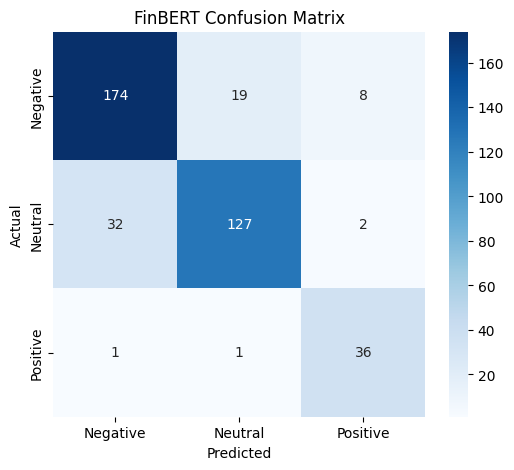

In [28]:
# Plot confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FinBERT Confusion Matrix")

plt.show()

In [29]:
# Save the confusion matrix plot

plt.savefig(PROJECT_ROOT / "results" / "finbert_confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [30]:
# Save predictions to a CSV file for analysis

results_df = pd.DataFrame({
    "text": X_test.values,
    "actual_sentiment": y_true,
    "predicted_sentiment": y_pred
})

RESULTS_PATH = PROJECT_ROOT / "results" / "hyperparameter_tuning_finbert_predictions.csv"

results_df.to_csv(RESULTS_PATH, index=False)

print("Predictions saved")

Predictions saved
